In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("train.csv", encoding='latin1')
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (119, 13)


In [4]:
print(df.columns)

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits',
       'Follows', 'Caption', 'Hashtags'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


In [6]:
df.describe()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,5703.991597,2475.789916,1887.512605,1078.100840,171.092437,153.310924,6.663866,9.361345,173.781513,50.621849,20.756303
std,4843.780105,1489.386348,1884.361443,2613.026132,289.431031,156.317731,3.544576,10.089205,82.378947,87.088402,40.921580
min,1941.000000,1133.000000,116.000000,0.000000,9.000000,22.000000,0.000000,0.000000,72.000000,4.000000,0.000000
25%,3467.000000,1945.000000,726.000000,157.500000,38.000000,65.000000,4.000000,3.000000,121.500000,15.000000,4.000000
50%,4289.000000,2207.000000,1278.000000,326.000000,74.000000,109.000000,6.000000,6.000000,151.000000,23.000000,8.000000
75%,6138.000000,2602.500000,2363.500000,689.500000,196.000000,169.000000,8.000000,13.500000,204.000000,42.000000,18.000000
max,36919.000000,13473.000000,11817.000000,17414.000000,2547.000000,1095.000000,19.000000,75.000000,549.000000,611.000000,260.000000


In [7]:
df.isnull().sum()

Impressions       0
From Home         0
From Hashtags     0
From Explore      0
From Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 17


In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(102, 13)

In [11]:
numeric_df = df.select_dtypes(include=np.number)

In [12]:
corr = numeric_df.corr()

In [13]:
corr

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows
Impressions,1.000000,0.850210,0.547337,0.895021,0.586628,0.791448,-0.008535,0.654920,0.852952,0.762679,0.889944
From Home,0.850210,1.000000,0.171849,0.805609,0.560149,0.786382,0.002763,0.693729,0.697192,0.537245,0.676961
From Hashtags,0.547337,0.171849,1.000000,0.177493,0.210705,0.285209,0.213391,0.211964,0.667107,0.692433,0.549309
From Explore,0.895021,0.805609,0.177493,1.000000,0.490258,0.769341,-0.152720,0.643606,0.655724,0.530046,0.795342
From Other,0.586628,0.560149,0.210705,0.490258,1.000000,0.335213,-0.081073,0.155730,0.388314,0.627791,0.537115
Saves,0.791448,0.786382,0.285209,0.769341,0.335213,1.000000,-0.003695,0.874004,0.843395,0.377424,0.647585
Comments,-0.008535,0.002763,0.213391,-0.152720,-0.081073,-0.003695,1.000000,0.012697,0.163383,0.136590,-0.029298
Shares,0.654920,0.693729,0.211964,0.643606,0.155730,0.874004,0.012697,1.000000,0.718790,0.265460,0.517278
Likes,0.852952,0.697192,0.667107,0.655724,0.388314,0.843395,0.163383,0.718790,1.000000,0.642658,0.758234
Profile Visits,0.762679,0.537245,0.692433,0.530046,0.627791,0.377424,0.136590,0.265460,0.642658,1.000000,0.852748


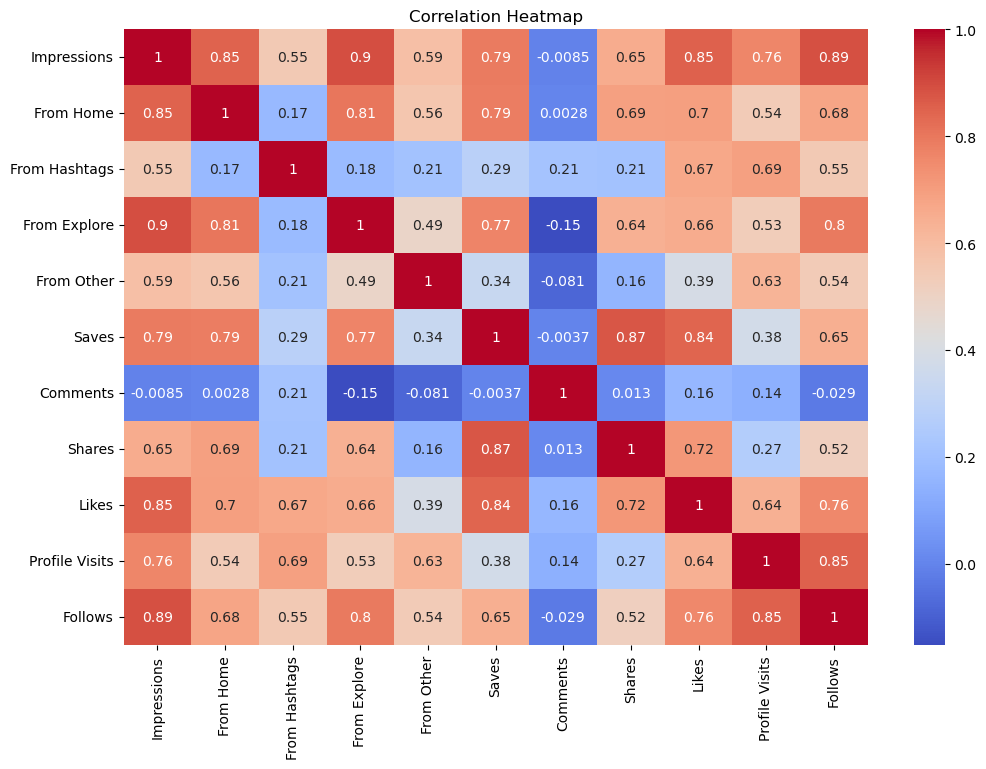

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

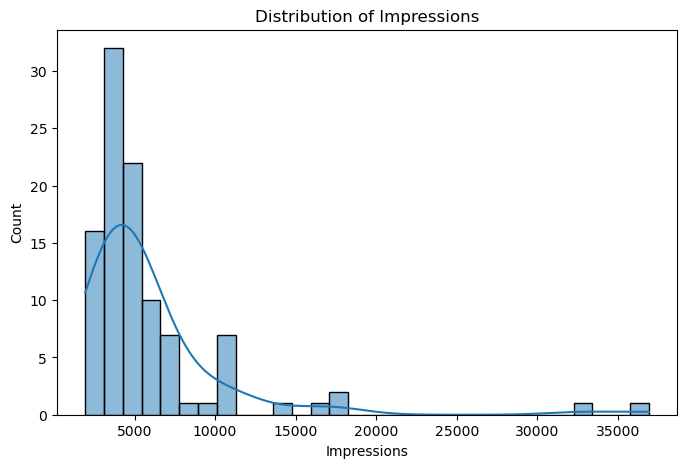

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Impressions'], kde=True)
plt.title("Distribution of Impressions")
plt.show()

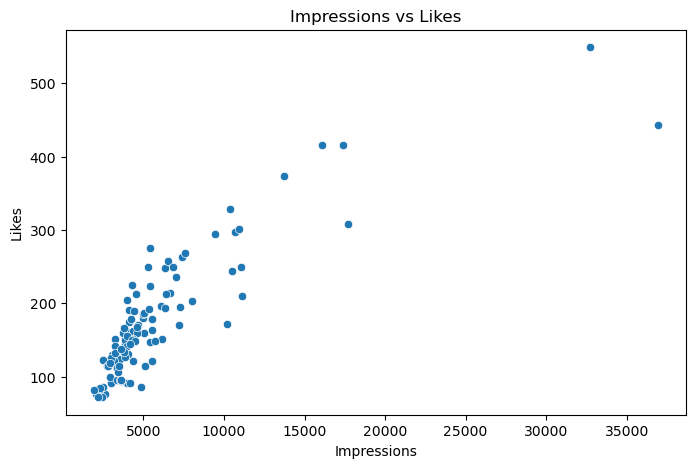

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Impressions', y='Likes', data=df)
plt.title("Impressions vs Likes")
plt.show()

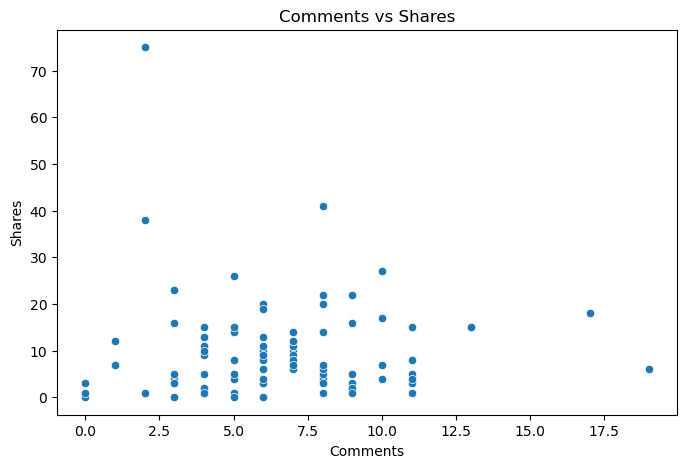

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Comments', y='Shares', data=df)
plt.title("Comments vs Shares")
plt.show()

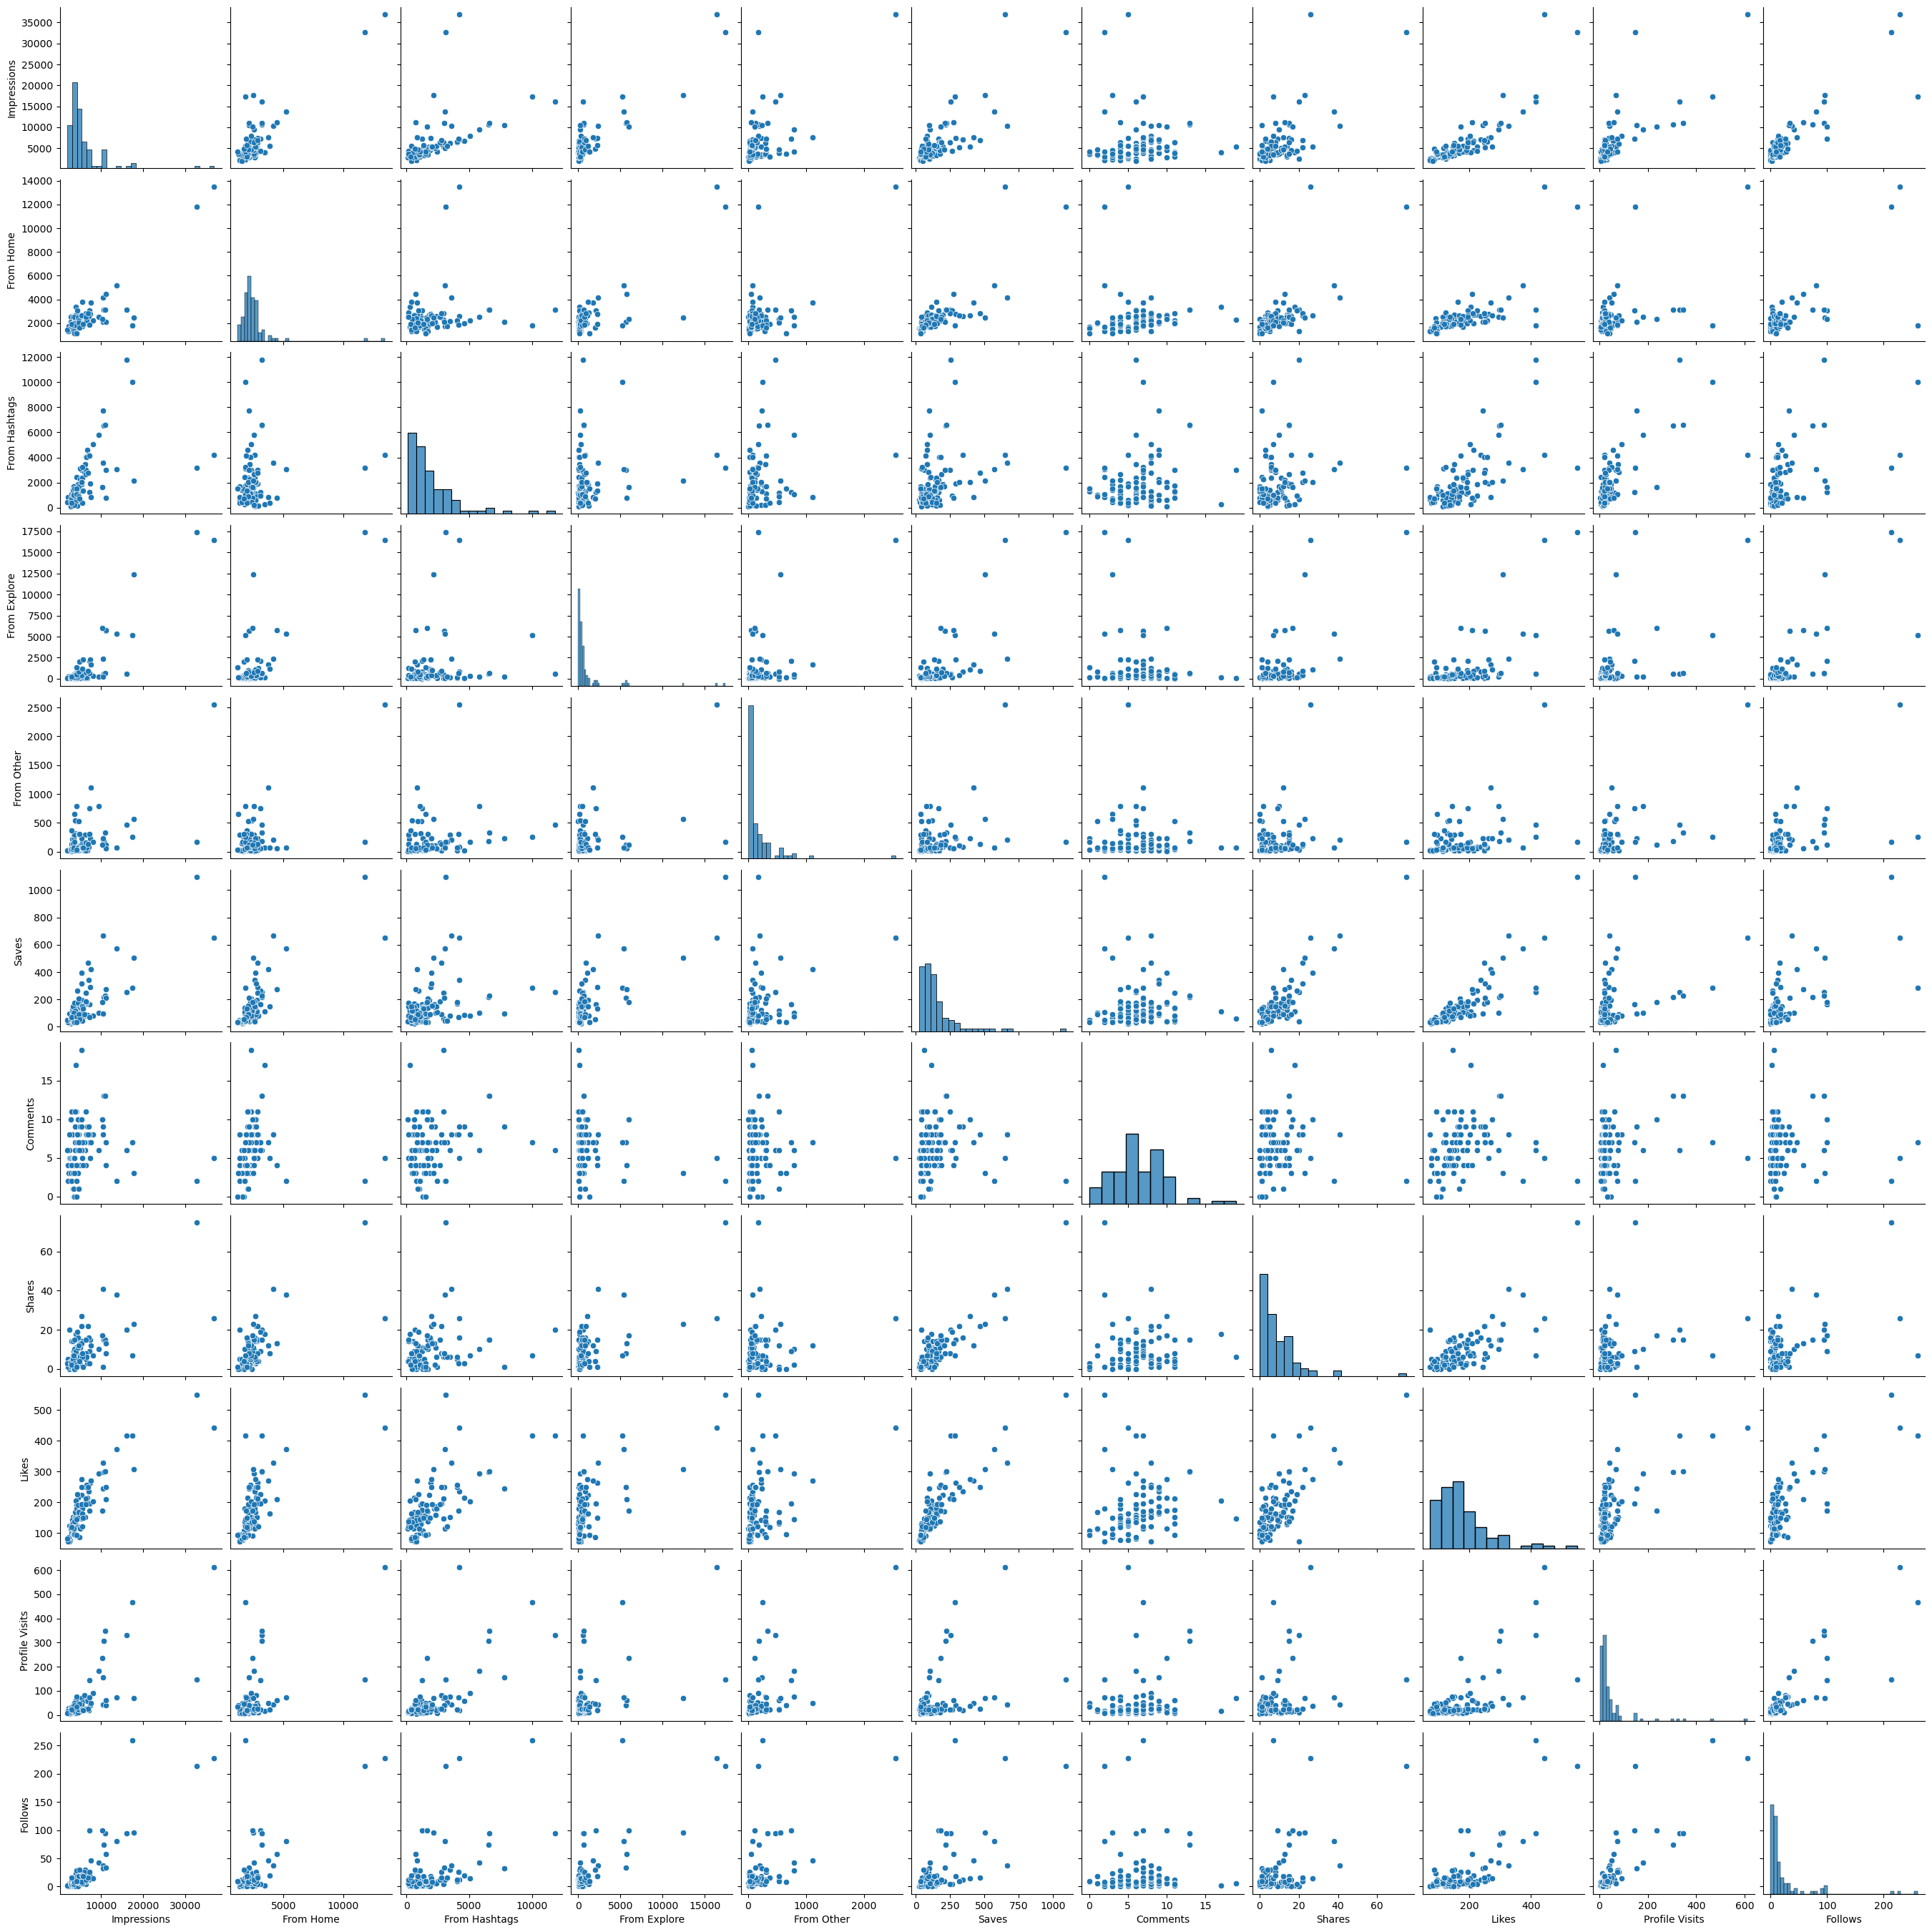

In [18]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

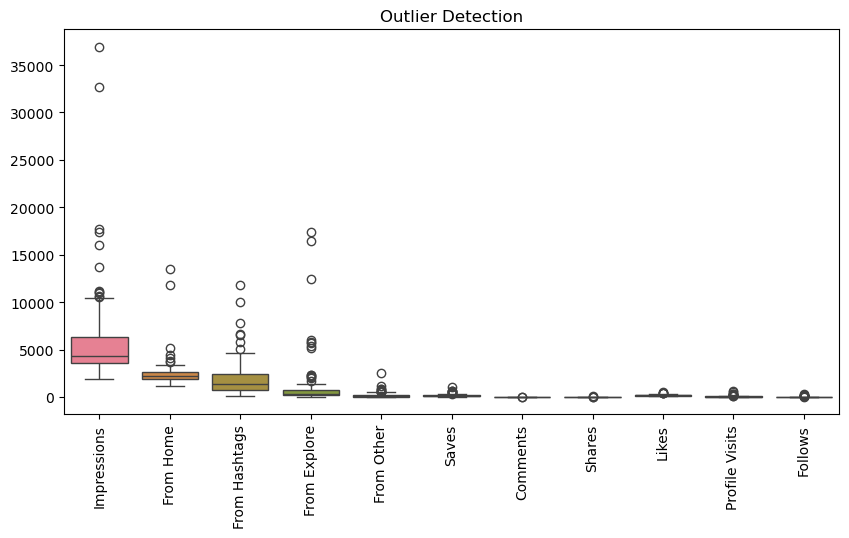

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [20]:
numeric_df.mean().sort_values(ascending=False)

Impressions       5920.254902
From Home         2496.911765
From Hashtags     1968.284314
From Explore      1178.568627
From Other         184.549020
Likes              176.823529
Saves              156.549020
Profile Visits      54.666667
Follows             22.823529
Shares               9.303922
Comments             6.352941
dtype: float64

In [21]:
top_likes = df.sort_values(by='Likes', ascending=False).head(10)
top_likes[['Likes', 'Impressions', 'Caption']]

,Likes,Impressions,Caption
117,549,32695,Here are some of the best data science certifi...
118,443,36919,175 Python Projects with Source Code solved an...
107,416,17396,Here is a list of 100+ Machine Learning Algori...
40,416,16062,280 Machine Learning Projects Solved & Explain...
114,373,13700,Here are some of the best data science certifi...
49,328,10386,Here are some of the best websites that you ca...
109,308,17713,Here are some of the best resources to learn S...
67,301,10933,170 Python Projects with Source Code solved an...
54,297,10667,170 Python Projects with Source Code solved an...
14,294,9453,Omicron Variant Sentiment Analysis using Pytho...


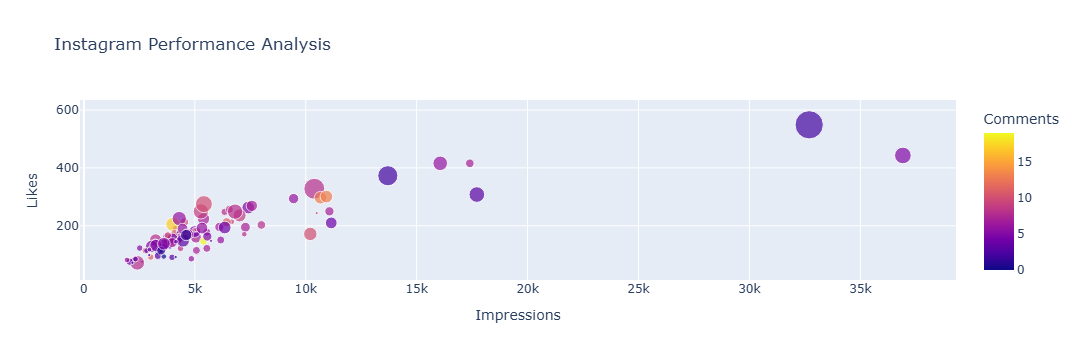

In [22]:
fig = px.scatter(
    df,
    x='Impressions',
    y='Likes',
    size='Shares',
    color='Comments',
    hover_data=['Follows'],
    title='Instagram Performance Analysis'
)
fig.show()

In [23]:
df['Engagement Rate'] = (
    df['Likes'] +
    df['Comments'] +
    df['Shares'] +
    df['Saves']
) / df['Impressions'] * 100
df[['Engagement Rate']].head()

,Engagement Rate
0,6.989796
1,8.138673
2,4.575976
3,8.878092
4,9.054805


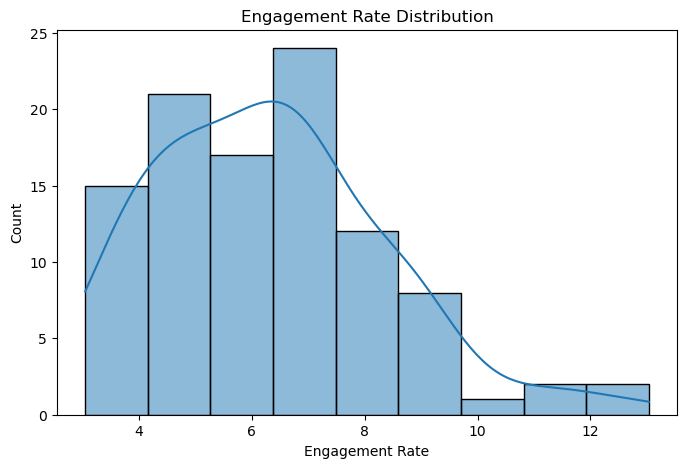

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['Engagement Rate'], kde=True)
plt.title("Engagement Rate Distribution")
plt.show()

In [25]:
top_engagement = df.sort_values(
    by='Engagement Rate',
    ascending=False
).head(10)
top_engagement[['Engagement Rate', 'Likes', 'Comments']]

,Engagement Rate,Likes,Comments
99,13.033833,275,10
45,11.935784,225,6
81,11.359757,250,9
108,10.977399,249,8
49,10.061621,328,8
64,9.364681,269,7
59,9.211337,132,5
72,9.206877,138,5
11,9.121831,151,8
4,9.054805,123,5


In [26]:
df['Hashtag Count'] = df['Hashtags'].astype(str).apply(lambda x: len(x.split()))
df[['Hashtag Count']].head()

,Hashtag Count
0,22
1,18
2,18
3,11
4,29


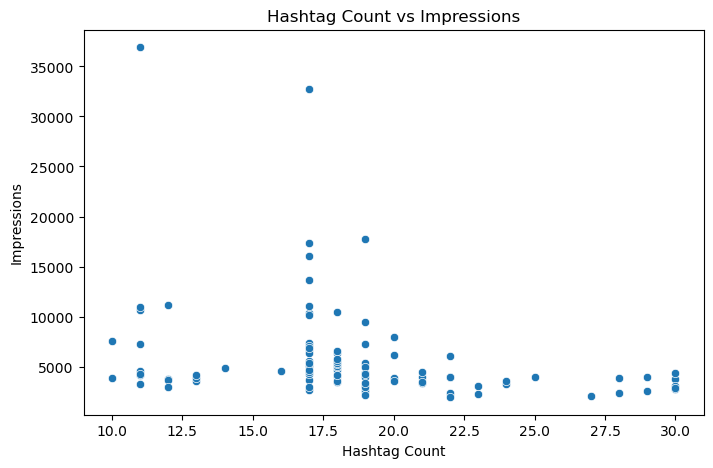

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Hashtag Count',
    y='Impressions',
    data=df
)
plt.title("Hashtag Count vs Impressions")
plt.show()

In [28]:
df.to_csv("cleaned_instagram_data.csv", index=False)